In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/Users/deepanshus/StockMarketPredictor/Project/data/Combined/all/unclean_data.csv")

In [3]:
print(df.head())

         rsi               macd           sma_ratio  volume_change  \
0  52.729384  5.231607300449525  1.0415025077232871            NaN   
1  54.632972  5.343970596287761  1.0404949907930463      -0.387146   
2  68.850806  6.284494881103626  1.0449560925821046       3.874652   
3  57.588533  6.152033909023714   1.046340554969272      -0.729922   
4        NaN  5.627148145610363  1.0467670817749986      -0.136228   

   volatility    target  
0    0.015705 -0.009905  
1    0.015875  0.033691  
2    0.015084 -0.028466  
3    0.018880 -0.012892  
4    0.019619  0.000297  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56831 entries, 0 to 56830
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rsi            51299 non-null  float64
 1   macd           51504 non-null  object 
 2   sma_ratio      51326 non-null  object 
 3   volume_change  51329 non-null  float64
 4   volatility     51165 non-null  float64
 5   target         51138 non-null  float64
dtypes: float64(4), object(2)
memory usage: 2.6+ MB
None


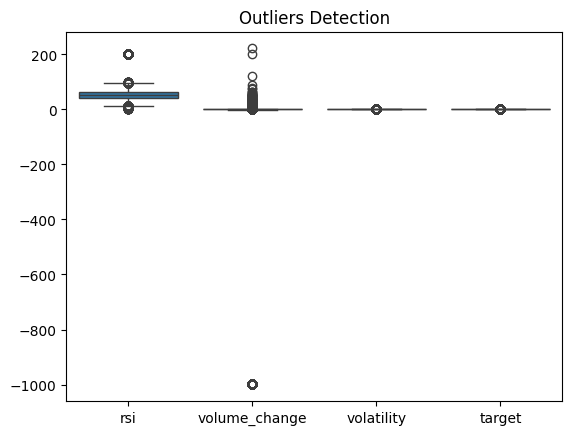

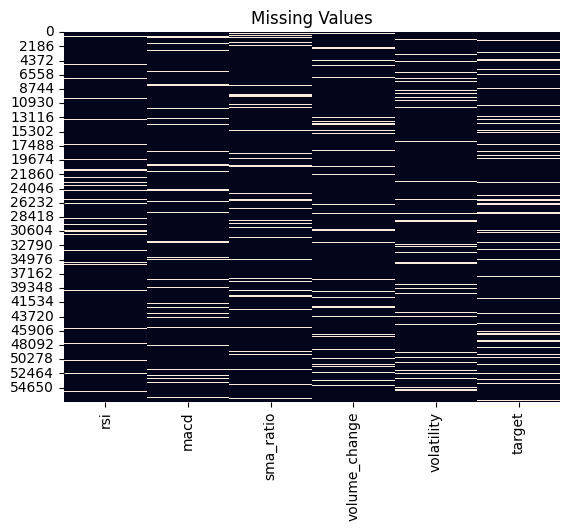

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

df.describe()

sns.boxplot(data=df.select_dtypes(include='number'))
plt.title("Outliers Detection")
plt.show()

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [6]:
df.replace(["ERROR", "?"], np.nan,)

,rsi,macd,sma_ratio,volume_change,volatility,target
0,52.729384,5.231607300449525,1.0415025077232871,NaN,0.015705,-0.009905
1,54.632972,5.343970596287761,1.0404949907930463,-0.387146,0.015875,0.033691
2,68.850806,6.284494881103626,1.0449560925821046,3.874652,0.015084,-0.028466
3,57.588533,6.152033909023714,1.046340554969272,-0.729922,0.018880,-0.012892
4,NaN,5.627148145610363,1.0467670817749986,-0.136228,0.019619,0.000297
...,...,...,...,...,...,...
56826,47.749974,-25.633603078309537,1.0063873076728784,0.423221,0.087078,NaN
56827,NaN,2.1357887759086793,NaN,0.038805,0.013527,-0.013503
56828,NaN,-248.1334982197459,0.9159677270547202,-0.215052,0.093271,0.014345
56829,16.279070,-0.8318808917745848,0.9248785885535132,0.014613,0.011344,0.045694


In [7]:
df.isnull().sum()

rsi              5532
macd             5327
sma_ratio        5505
volume_change    5502
volatility       5666
target           5693
dtype: int64

In [8]:
df.replace(["ERROR", "?"], np.nan, inplace=True)

df = df.apply(pd.to_numeric, errors='coerce')

In [9]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 3065


In [10]:
df.isnull().sum()

rsi              5245
macd             6641
sma_ratio        6880
volume_change    5246
volatility       5402
target           5404
dtype: int64

In [11]:
for col in df.columns:
    df[col].fillna(df[col].median(), inplace=True)

In [12]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [13]:
df["market_trend"] = np.where(df["rsi"] > 60, "bull",
                      np.where(df["rsi"] < 40, "bear", "neutral"))

In [14]:
freq = df["market_trend"].value_counts(normalize=True)

rare = freq[freq < 0.05].index

df["market_trend"] = df["market_trend"].replace(rare, "other")

In [15]:
# Example features
df["volatility_ratio"] = df["volatility"] / df["sma_ratio"]
df["momentum"] = df["macd"] * df["rsi"]

In [16]:
df = pd.get_dummies(df, columns=["market_trend"], drop_first=True)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop("target", axis=1)
y = df["target"]

X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled["target"] = y.values

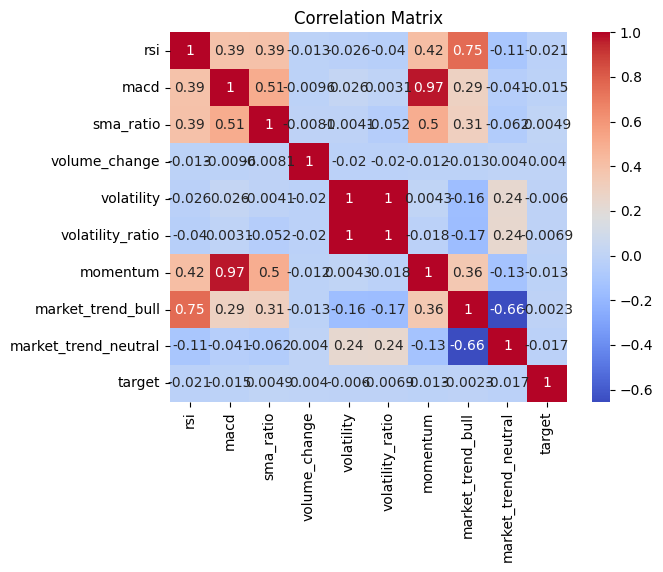

In [18]:
sns.heatmap(df_scaled.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [20]:
# df_scaled.to_csv("final_processed_data.csv", index=False)